## Defuzzification methods

### Step 1: Import Library

In [1]:
import numpy as np

### Step 2: Given fuzzy output (speed vs Membership)

In [2]:
x = np.array([20,40,60,80,100]) #speed values (level of Aggration)(defencive,balanced,attacking,very,aggracise,riskyshot)
mu = np.array([0.2,0.5,0.9,0.6,0.3]) #membership values

## Interpretation:
-> x represents speed values (crisp domain)

-> mu represents membership degree


In [31]:
x_new = np.array([20,40,60,80,100]) #speed values (level of Aggration)
mu_new = np.array([0.2,0.6,0.12,0.5,0.8]) #membership values

In [38]:
x_new_p = np.array([20,40,60,80,100]) #speed values (level of Aggration)
mu_new_p = np.array([0.2,0.6,0.9,0.7,0.3]) #membership values

### Step 3: Method 1 -> Centroid method 

In [43]:
def centroid(x,mu):
    return np.sum(x*mu) / np.sum(mu)

print("Centroid Value: Attacking", centroid(x,mu))
print("New Centroid Value: Attacking ", centroid(x_new,mu_new))
print("New Centroid Value: Attacking", centroid(x_new_p,mu_new_p))

Centroid Value: Attacking 62.4
New Centroid Value: Attacking  69.90990990990991
New Centroid Value: Attacking 62.22222222222222


## Interpretation:
-> Gives the center of gravity of the fuzzy set

->It considers all values and their weights

->Result is usually balanced and smooth

The centroid value represents the overall weighted average decision, considering all membership values.

### Step 4: Method 2 -> Bisector Method

In [44]:
def bisector(x, mu):
    total_area = np.sum(mu)
    half_area = total_area / 2.0
    cumulative = 0

    for i in range(len(x)):
        cumulative += mu[i]
        if cumulative >= half_area:
            return x[i]

print("Bisector value: Attacking ", bisector(x,mu))
print("New Bisector  Value: Very Aggrasive ", bisector(x_new,mu_new))
print("New Bisector  Value: Attacking ", bisector(x_new_p,mu_new_p))

Bisector value: Attacking  60
New Bisector  Value: Very Aggrasive  80
New Bisector  Value: Attacking  60


## Interpretation:
->Divides the area into two equal halves

->Finds the point where:

-Left area = Right area

## Meaning:

The bisector gives a value where the fuzzy set is evenly distributed, not biased toward peaks.

### Step 5: Method 3 -> Maximum of Membership Method

In [45]:
def MOM(x,mu):
    index = np.argmax(mu)
    return x[index]

print("Maximum Value: Attacking",MOM(x,mu))
print("Maximum Value: Risky Shot", MOM(x_new,mu_new))
print("Maximum Value: Attacking", MOM(x_new_p,mu_new_p))

Maximum Value: Attacking 60
Maximum Value: Risky Shot 100
Maximum Value: Attacking 60


## Interpretation:
->Selects the value with highest membership

Here:

-> Max μ = 0.9 → x = 60

-> Meaning:

The system chooses the most confident (strongest) value.

In [21]:
def max_membership(x,mu):
    max_mu = np.max(mu)
    indices = np.where(mu == max_mu)
    return x[indices][0]

print("Maximum Value",max_membership(x,mu))

Maximum Value 60


### Step 6: Graph Visualization

In [22]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Membership Value')

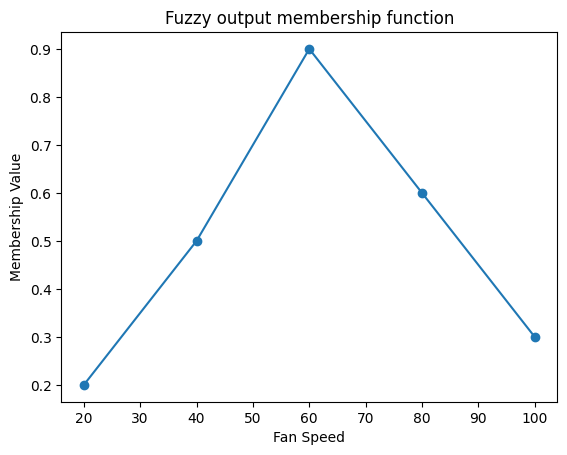

In [23]:
plt.plot(x,mu,marker="o")
plt.title("Fuzzy output membership function")
plt.xlabel("Fan Speed")
plt.ylabel("Membership Value")


## Interpretation:
Curve shows membership function

Vertical lines show defuzzified values:



| Line           | Meaning                   |
| -------------- | ------------------------- |
| Centroid       | Balanced overall decision |
| Bisector       | Equal area division       |
| Max Membership | Highest confidence value  |


Text(0, 0.5, 'Membership Value')

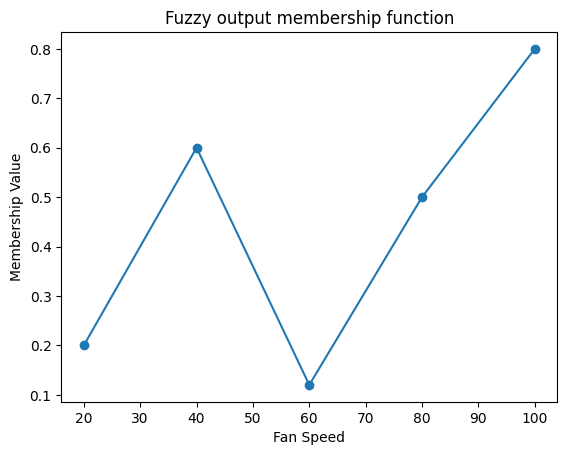

In [35]:
plt.plot(x_new,mu_new,marker="o")
plt.title("Fuzzy output membership function")
plt.xlabel("Fan Speed")
plt.ylabel("Membership Value")

### Print Defuzzified values

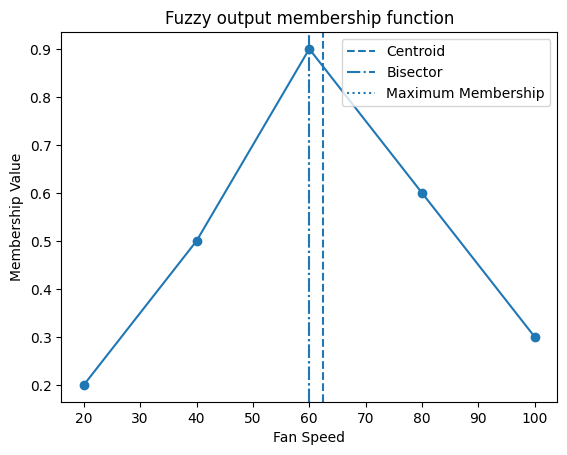

In [29]:
plt.plot(x,mu,marker="o")
plt.title("Fuzzy output membership function")
plt.xlabel("Fan Speed")
plt.ylabel("Membership Value")

plt.axvline(centroid(x, mu), linestyle='--', label='Centroid')
plt.axvline(bisector(x, mu), linestyle='-.', label='Bisector')
plt.axvline(max_membership(x, mu), linestyle=':', label='Maximum Membership')

plt.legend()
plt.show()

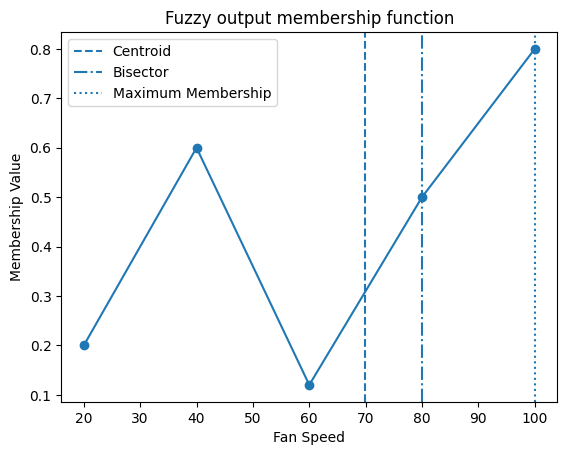

In [36]:
plt.plot(x_new,mu_new,marker="o")
plt.title("Fuzzy output membership function")
plt.xlabel("Fan Speed")
plt.ylabel("Membership Value")

plt.axvline(centroid(x_new, mu_new), linestyle='--', label='Centroid')
plt.axvline(bisector(x_new, mu_new), linestyle='-.', label='Bisector')
plt.axvline(max_membership(x_new, mu_new), linestyle=':', label='Maximum Membership')

plt.legend()
plt.show()

## Final Conclusion 

Different defuzzification methods produce different crisp values from the same fuzzy set. The centroid method provides a balanced output, bisector ensures equal area division, and maximum membership selects the most dominant value. The choice of method depends on application requirements such as accuracy, simplicity, or interpretability.